## Univariate and Bivariate Exploratory Data Analysis - Indian Road Accident Dataset (2022–2025)

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df=pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\EDA project\data\interim\cleaned_day2")
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


## UNIVARIATE ANALYSIS

## 1. Casualties Distribution (Histogram)

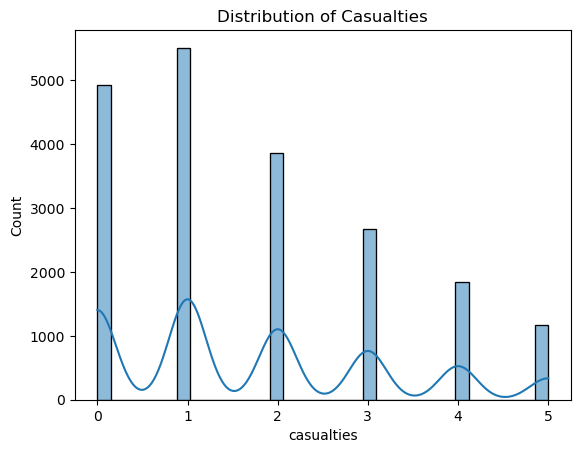

In [23]:
sns.histplot(df['casualties'], kde=True)
plt.title("Distribution of Casualties")
plt.show()

### Insights & Findings:
Most accidents involve a low number of casualties, with the majority clustered around smaller values. High-casualty incidents are rare, indicating that severe accidents are less frequent but still significant when they occur.

## 2. Vehicles Involved (Boxplot)

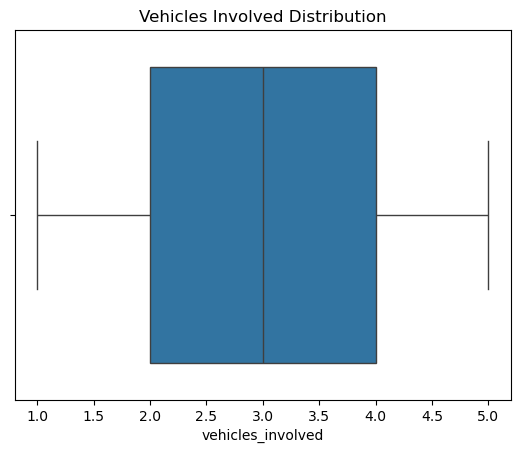

In [24]:
sns.boxplot(x=df['vehicles_involved'])
plt.title("Vehicles Involved Distribution")
plt.show()

### Insights & Findings:

The number of vehicles involved in accidents is generally low, typically between 1 and 3. This suggests that most accidents are minor collisions rather than large multi-vehicle incidents.

## 3. Accident Severity (Bar Chart)

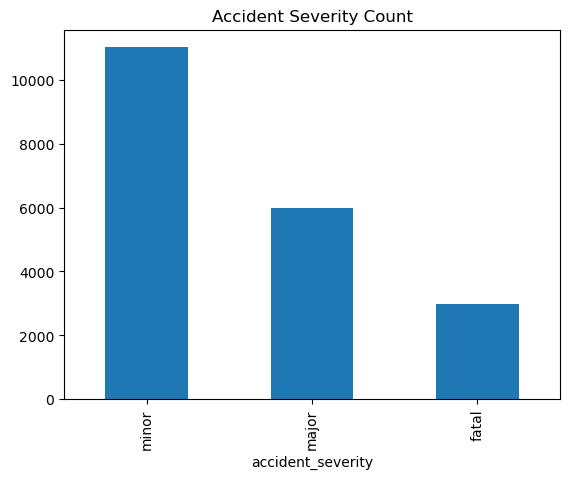

In [25]:
df['accident_severity'].value_counts().plot(kind='bar')
plt.title("Accident Severity Count")
plt.show()

### Insights & Findings:

Minor accidents dominate the dataset, followed by major and fatal accidents. This indicates that while accidents are common, the majority do not result in extreme severity.

## 4. Weather Distribution


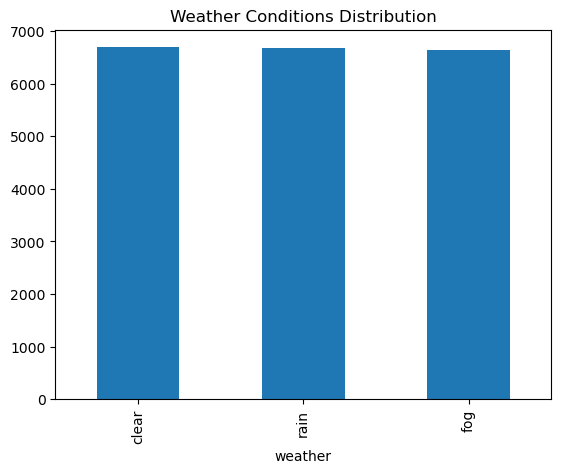

In [26]:
df['weather'].value_counts().plot(kind='bar')
plt.title("Weather Conditions Distribution")
plt.show()

### Insights & Findings:

Accidents occur under various weather conditions, including normal conditions. This suggests that factors other than weather, such as human behavior or traffic conditions, play a significant role in accidents.

## BIVARIATE ANALYSIS

## 5. Vehicles vs Casualties (Scatterplot)

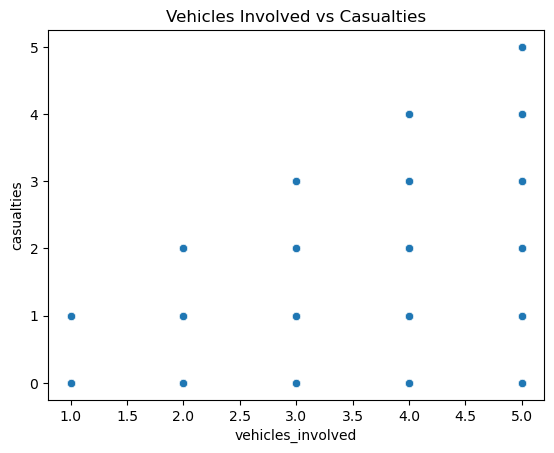

In [27]:
sns.scatterplot(x='vehicles_involved', y='casualties', data=df)
plt.title("Vehicles Involved vs Casualties")
plt.show()

## Insights & Findings:

There is a positive relationship between vehicles involved and casualties. Accidents involving more vehicles tend to result in higher casualties, indicating increased risk in multi-vehicle collisions.

## 6. Correlation Heatmap

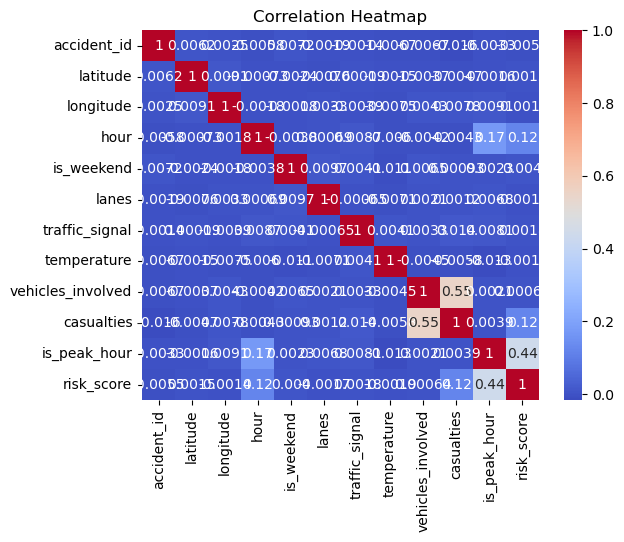

In [28]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Insights & Findings:

The correlation between variables is generally weak to moderate. This indicates that accident outcomes are influenced by multiple factors rather than a single dominant variable.

## 7. Severity vs Casualties (Boxplot)

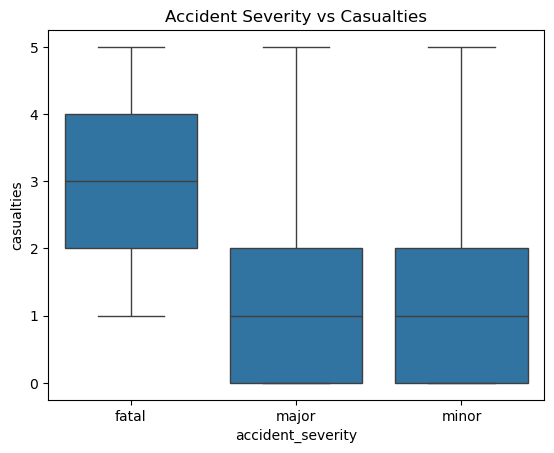

In [29]:
sns.boxplot(x='accident_severity', y='casualties', data=df)
plt.title("Accident Severity vs Casualties")
plt.show()

### Insights & Findings:

Higher accident severity levels are associated with increased casualties. Fatal and major accidents show significantly higher casualty counts compared to minor accidents.

## 8. Weather vs Severity (Grouped Bar)

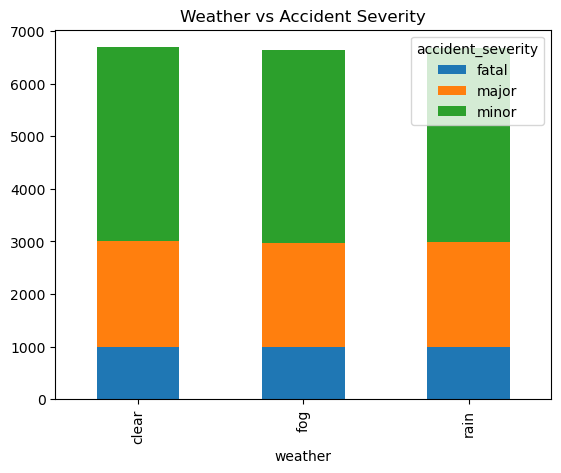

In [30]:
pd.crosstab(df['weather'], df['accident_severity']).plot(kind='bar', stacked=True)
plt.title("Weather vs Accident Severity")
plt.show()

### Insights & Findings:

Accident severity varies across weather conditions. Certain conditions appear to have a higher proportion of severe accidents, suggesting environmental factors can influence accident impact.

## 9. State-wise Casualties (Segment Analysis)

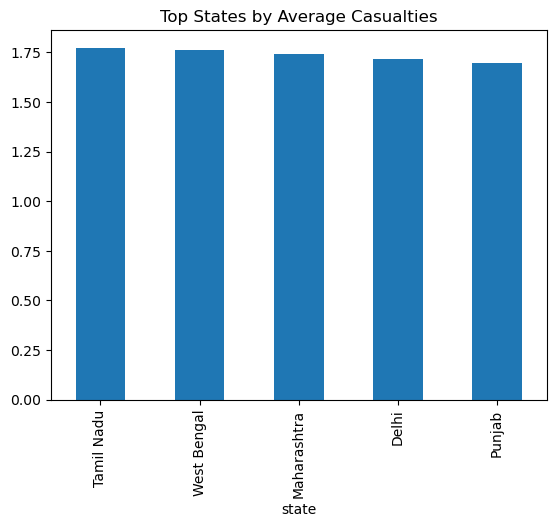

In [31]:
df.groupby('state')['casualties'].mean().sort_values(ascending=False).head().plot(kind='bar')
plt.title("Top States by Average Casualties")
plt.show()

### Insights & Findings:

Some states have higher average casualties than others, indicating regional differences in road safety, infrastructure, and traffic conditions.

## Overall Findings

- Most accidents are minor with low casualties
- Multi-vehicle accidents tend to increase casualties
- Accident severity is strongly linked to casualty count
- Weather has some impact, but is not the only factor
- Regional differences exist in accident severity

In [35]:
df.to_csv(r"C:\Users\Lenovo\OneDrive\Desktop\EDA project\notebooks\Day3_figures" , index=False)